## Downloads data from DAHITI

In [ ]:
# setup imports
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))
from src.io import download_dahiti_water_level
from src.paths import BATHYMETRY, DAHITI

In [2]:
print(DAHITI)

/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


In [ ]:
API_KEY = os.getenv("DAHITI_API_KEY")      #changed from hardcoded value to environment variable

if not API_KEY:
    raise ValueError("DAHITI_API_KEY not found in environment variables. Please check your .env file.")

# Download as netCDF
file_paths = download_dahiti_water_level(
    dahiti_ids=[81, 82, 83, 442], api_key=API_KEY, file_format="netcdf", download_folder=DAHITI
)
print(f"NetCDF file saved at: {file_paths}")

NetCDF file saved at: {81: '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti/81_water_level.nc', 82: '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti/82_water_level.nc', 83: '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti/83_water_level.nc', 442: '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti/442_water_level.nc'}


Found 4 NetCDF files.


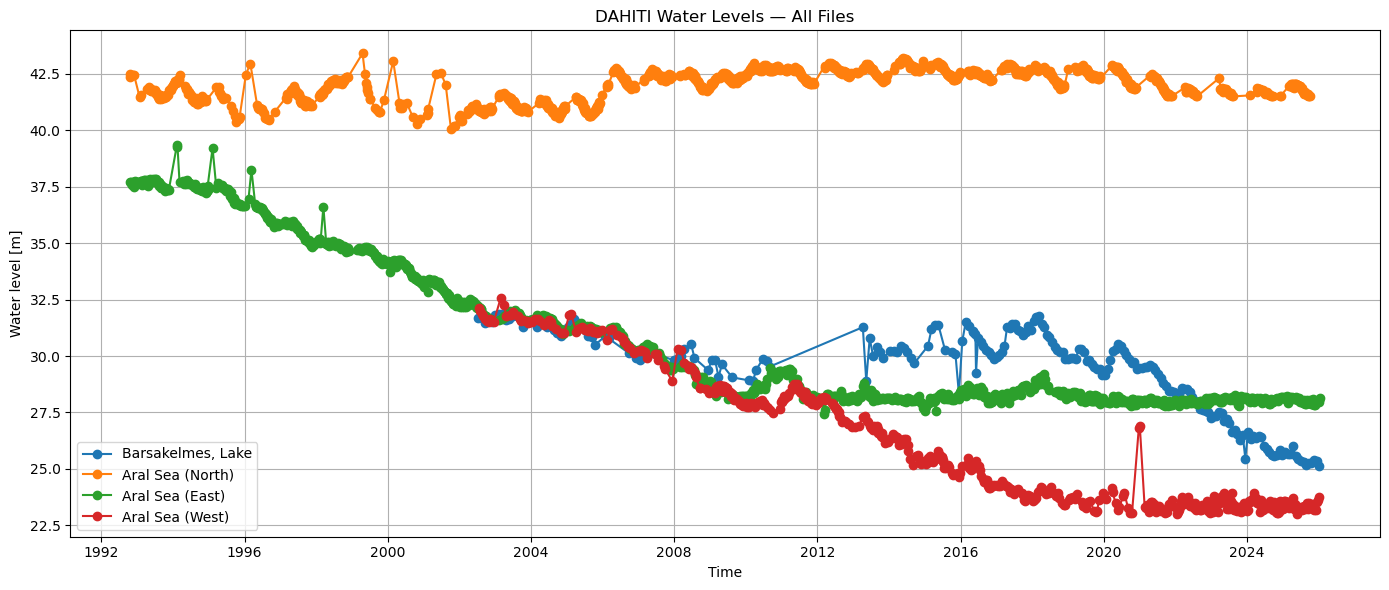

In [10]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# Base folder where your folders/files are
base_folder = DAHITI

# Find all NetCDF files recursively
nc_files = glob.glob(os.path.join(base_folder, "**", "*.nc"), recursive=True)
print(f"Found {len(nc_files)} NetCDF files.")

plt.figure(figsize=(14, 6))

# Loop through each file
for file_path in nc_files:
    ds = xr.open_dataset(file_path)

    # Convert datetime strings to pandas datetime
    time = pd.to_datetime(ds["datetime"].values)
    water_level = ds["water_level"].values

    # Use filename (without extension) as label
    label = os.path.splitext(os.path.basename(file_path))[0]

    # Plot on the same figure
    plt.plot(time, water_level, marker="o", linestyle="-", label=f"{ds.target_name}")

# Finalize plot
plt.xlabel("Time")
plt.ylabel("Water level [m]")
plt.title("DAHITI Water Levels — All Files")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
file_intas = BATHYMETRY / "Nachtnebel_table.csv"
intas_bathy = pd.read_csv(file_intas, sep=";", decimal=",")
print(file_intas)

/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv


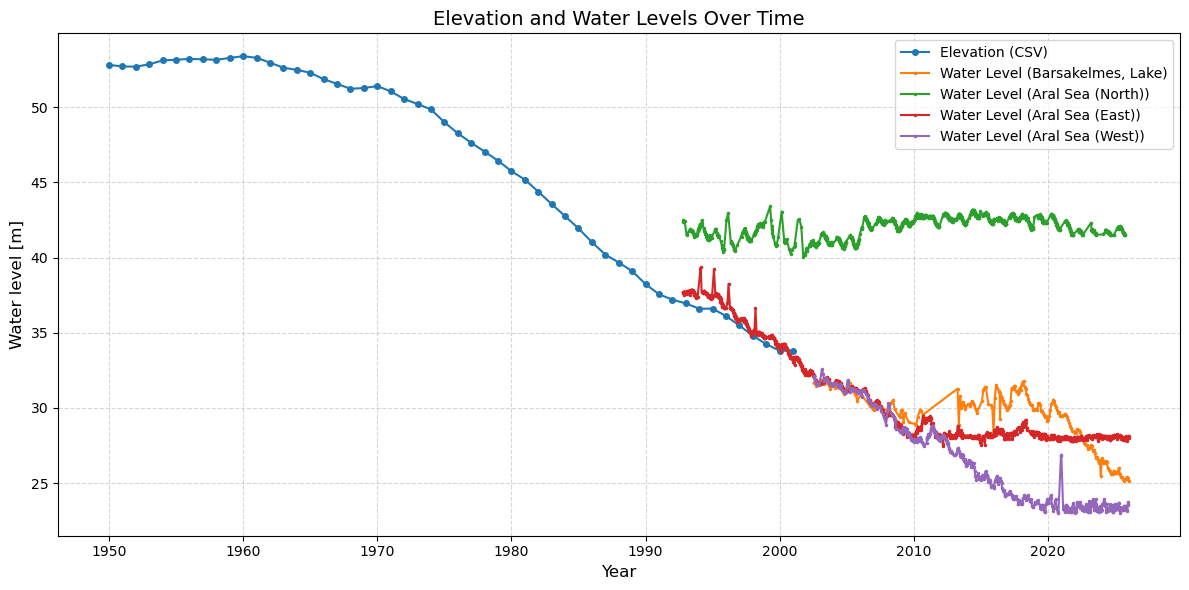

In [16]:
# --- CSV elevation data ---
# Convert 'Year' to datetime (only year)
intas_bathy["Year"] = pd.to_datetime(intas_bathy["Year"], format="%Y")
intas_bathy["elevation"] = intas_bathy["elevation"].astype(float)

# --- Plot setup ---
plt.figure(figsize=(12, 6))

# Plot CSV without forcing color
plt.plot(
    intas_bathy["Year"],
    intas_bathy["elevation"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="Elevation (CSV)",
)

# Plot NetCDF files (automatic colors)
for file_path in nc_files:
    ds = xr.open_dataset(file_path)
    time = pd.to_datetime(ds["datetime"].values)
    water_level = ds["water_level"].values
    plt.plot(
        time,
        water_level,
        marker=".",
        markersize=3,
        linestyle="-",
        label=f"Water Level ({ds.target_name})",
    )

# --- Customize plot ---
plt.xlabel("Year", fontsize=12)
plt.ylabel("Water level [m]", fontsize=12)
plt.title("Elevation and Water Levels Over Time", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()